# 03 - Baseline: Multinomial Naive Bayes

Este notebook entrena y evalua el modelo baseline usando **Multinomial Naive Bayes** sobre la codificacion BoW generada en `02_encoding.ipynb`.

## Flujo
1. Cargar los artefactos de `02_encoding.ipynb` (matrices sparse + labels).
2. Entrenar `MultinomialNB` sobre `X_tr`.
3. Ajustar el hiperparametro `alpha` usando `X_val`.
4. Re-entrenar el modelo final con `X_train_bow` completo.
5. Evaluar **una sola vez** sobre `X_test_bow` y reportar metricas.
6. Guardar el modelo final.

## Politica de evaluacion
| Conjunto | Uso en este notebook |
|---|---|
| `X_tr` | Entrenar durante ajuste de hiperparametros |
| `X_val` | Medir rendimiento para elegir mejor `alpha` |
| `X_train_bow` | Entrenamiento final con todos los datos de train |
| `X_test_bow` | Evaluacion final unica — no se usa antes de este paso |

## 1. Instalacion e imports

In [1]:
!pip install -q scikit-learn scipy joblib matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import load_npz
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score,
    f1_score
)

SEED = 42
print('OK - Imports listos. SEED:', SEED)

OK - Imports listos. SEED: 42


## 2. Carga de artefactos

Cargamos las matrices sparse y labels generados en `02_encoding.ipynb`.

| Variable | Archivo | Descripcion |
|---|---|---|
| `X_tr` | `X_tr.npz` | 80% del train para desarrollo |
| `X_val` | `X_val.npz` | 20% del train para validacion |
| `X_train_bow` | `X_train_bow.npz` | Train completo para entrenamiento final |
| `X_test_bow` | `X_test_bow.npz` | Test reservado para evaluacion final |

In [3]:
X_tr        = load_npz('X_tr.npz')
X_val       = load_npz('X_val.npz')
X_train_bow = load_npz('X_train_bow.npz')
X_test_bow  = load_npz('X_test_bow.npz')

y_tr        = joblib.load('y_tr.pkl')
y_val       = joblib.load('y_val.pkl')
y_train     = joblib.load('y_train.pkl')
y_test      = joblib.load('y_test.pkl')

print('X_tr:        ', X_tr.shape)
print('X_val:       ', X_val.shape)
print('X_train_bow: ', X_train_bow.shape)
print('X_test_bow:  ', X_test_bow.shape)

X_tr:         (1088000, 39160)
X_val:        (272000, 39160)
X_train_bow:  (1360000, 39160)
X_test_bow:   (240000, 39160)


## 3. Que es Multinomial Naive Bayes?

Naive Bayes es un clasificador probabilistico basado en el **teorema de Bayes**. Asume que todas las features (palabras) son independientes entre si — de ahi el nombre *naive* (ingenuo).

La variante **Multinomial** es la adecuada para BoW porque trabaja con conteos de palabras (valores enteros >= 0).

### Hiperparametro clave: `alpha` (Laplace smoothing)
- `alpha` evita probabilidades de cero para palabras que no aparecieron en el entrenamiento.
- Valor por defecto: `1.0` (suavizado de Laplace estandar).
- Valores mas bajos hacen el modelo mas sensible a las frecuencias reales.
- Valores mas altos suavizan mas las probabilidades.

## 4. Ajuste de hiperparametro `alpha`

Probamos distintos valores de `alpha` entrenando sobre `X_tr` y midiendo F1 en `X_val`.
El test (`X_test_bow`) no se toca en este paso.

In [4]:
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
results_alpha = []

for alpha in alphas:
    mnb = MultinomialNB(alpha=alpha)
    mnb.fit(X_tr, y_tr)
    y_pred_val = mnb.predict(X_val)
    f1  = f1_score(y_val, y_pred_val, average='macro')
    acc = accuracy_score(y_val, y_pred_val)
    results_alpha.append({'alpha': alpha, 'f1_macro': round(f1, 4), 'accuracy': round(acc, 4)})
    print(f'alpha={alpha:<5} | F1 macro: {f1:.4f} | Accuracy: {acc:.4f}')

df_alpha = pd.DataFrame(results_alpha)
best_alpha = df_alpha.loc[df_alpha['f1_macro'].idxmax(), 'alpha']
print(f'\nMejor alpha: {best_alpha}')

alpha=0.01  | F1 macro: 0.7567 | Accuracy: 0.7567
alpha=0.05  | F1 macro: 0.7570 | Accuracy: 0.7570
alpha=0.1   | F1 macro: 0.7572 | Accuracy: 0.7572
alpha=0.5   | F1 macro: 0.7582 | Accuracy: 0.7582
alpha=1.0   | F1 macro: 0.7586 | Accuracy: 0.7587
alpha=2.0   | F1 macro: 0.7592 | Accuracy: 0.7592
alpha=5.0   | F1 macro: 0.7598 | Accuracy: 0.7598

Mejor alpha: 5.0


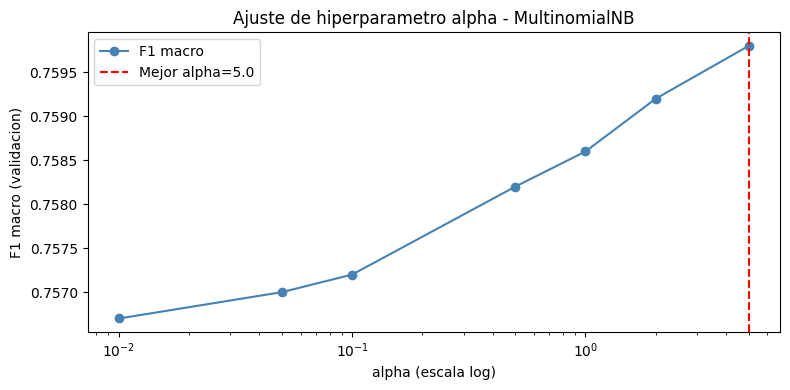

In [5]:
# Grafica de F1 vs alpha
plt.figure(figsize=(8, 4))
plt.plot(df_alpha['alpha'], df_alpha['f1_macro'], marker='o', color='steelblue', label='F1 macro')
plt.axvline(x=best_alpha, color='red', linestyle='--', label=f'Mejor alpha={best_alpha}')
plt.xscale('log')
plt.xlabel('alpha (escala log)')
plt.ylabel('F1 macro (validacion)')
plt.title('Ajuste de hiperparametro alpha - MultinomialNB')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Entrenamiento final

Con el mejor `alpha` encontrado, re-entrenamos el modelo usando **todo el train** (`X_train_bow`).

Esto maximiza los datos disponibles para el modelo final antes de la evaluacion.

In [6]:
model_final = MultinomialNB(alpha=best_alpha)
model_final.fit(X_train_bow, y_train)

print(f'Modelo entrenado con alpha={best_alpha} sobre {X_train_bow.shape[0]:,} documentos.')

Modelo entrenado con alpha=5.0 sobre 1,360,000 documentos.


## 6. Evaluacion final sobre Test

Este es el unico momento en que usamos `X_test_bow`. Las metricas obtenidas aqui representan el **rendimiento real del modelo** sobre datos nunca vistos.

### Metricas reportadas
| Metrica | Descripcion |
|---|---|
| **Accuracy** | % de predicciones correctas sobre el total |
| **Precision** | De los predichos positivos, cuantos son realmente positivos |
| **Recall** | De los realmente positivos, cuantos detecta el modelo |
| **F1 macro** | Media armonica entre precision y recall (metrica principal) |
| **ROC-AUC** | Capacidad del modelo de separar las dos clases (0 a 1) |

In [7]:
y_pred  = model_final.predict(X_test_bow)
y_proba = model_final.predict_proba(X_test_bow)[:, 1]

acc     = accuracy_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred, average='macro')
auc     = roc_auc_score(y_test, y_proba)

print('=== EVALUACION FINAL - MultinomialNB ===')
print(f'Accuracy:  {acc:.4f}')
print(f'F1 macro:  {f1:.4f}')
print(f'ROC-AUC:   {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Negativo (0)', 'Positivo (1)']))

=== EVALUACION FINAL - MultinomialNB ===
Accuracy:  0.7600
F1 macro:  0.7600
ROC-AUC:   0.8353

              precision    recall  f1-score   support

Negativo (0)       0.76      0.75      0.76    120129
Positivo (1)       0.76      0.77      0.76    119871

    accuracy                           0.76    240000
   macro avg       0.76      0.76      0.76    240000
weighted avg       0.76      0.76      0.76    240000



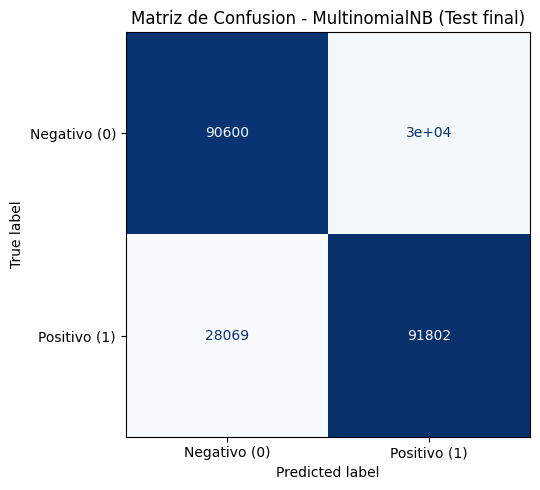

In [8]:
# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negativo (0)', 'Positivo (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusion - MultinomialNB (Test final)')
plt.tight_layout()
plt.show()

## 7. Guardar modelo y resultados

Guardamos el modelo final y un resumen de metricas para poder compararlo con otros modelos en el futuro.

In [9]:
joblib.dump(model_final, 'mnb_model.pkl')

results_final = pd.DataFrame([{
    'modelo':    'MultinomialNB',
    'alpha':     best_alpha,
    'accuracy':  round(acc, 4),
    'f1_macro':  round(f1, 4),
    'roc_auc':   round(auc, 4)
}])

results_final.to_csv('results_baseline.csv', index=False)

print('Archivos guardados:')
print('  mnb_model.pkl        -> modelo MultinomialNB final')
print('  results_baseline.csv -> tabla de metricas')
print()
print(results_final.to_string(index=False))

Archivos guardados:
  mnb_model.pkl        -> modelo MultinomialNB final
  results_baseline.csv -> tabla de metricas

       modelo  alpha  accuracy  f1_macro  roc_auc
MultinomialNB    5.0      0.76      0.76   0.8353
